# HW 3

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import pylab
params = {'xtick.labelsize': 18,
 'ytick.labelsize': 18,
 'axes.titlesize' : 22,
 'axes.labelsize' : 20,
 'legend.fontsize': 18,
 'legend.title_fontsize': 22,
 'figure.titlesize': 24 }
pylab.rcParams.update(params)

In [46]:
!rm *.csv

from google.colab import files
print("Please load the raw csv data")
uploadedData = files.upload()
filename = list(uploadedData)[0]

Please load the raw csv data


Saving DATA HW3 REAL.csv to DATA HW3 REAL.csv


In [47]:
dataset = pd.read_csv(filename)
dataset.shape

(1250, 12)

## Task

In [48]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(dataset, test_size=0.2, train_size=0.8, random_state=74)

In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler

FILL_NA_FIELDS = ["PCR_02"]
MINMAX_NORMALIZE_FIELDS = ["PCR_01","PCR_03","PCR_04","PCR_06","PCR_08", "happiness_score"]
STANDARD_NORMALIZE_FIELDS = ["PCR_02","PCR_05","PCR_07","PCR_09","PCR_10"]

# Helper function, makes a list of medians for required fields
def calc_fields_median(training_data, fields):
  medians = []

  for field in fields:
    medians.append(training_data[field].median())

  return medians

def prepare_data(training_data, new_data):
  # We will work on a copy of new_data to not change it
  new_data_processed = new_data.copy()

  # Calculate required medians from training_data to fill new_data
  medians = calc_fields_median(training_data, FILL_NA_FIELDS)

  # Fill copy of new_data null values with medians calculated before.
  for field, field_median in zip(FILL_NA_FIELDS, medians):
    new_data_processed[field] = new_data_processed[field].fillna(field_median)

  # Initialize scalers
  mm_scaler = MinMaxScaler(feature_range=(-1,1))
  std_scaler = StandardScaler()

  # Apply scalers on required columns
  new_data_processed[MINMAX_NORMALIZE_FIELDS] = mm_scaler.fit_transform(new_data_processed[MINMAX_NORMALIZE_FIELDS])
  new_data_processed[STANDARD_NORMALIZE_FIELDS] = StandardScaler().fit_transform(new_data_processed[STANDARD_NORMALIZE_FIELDS])

  return new_data_processed


In [50]:
# will be used up to section 5
all_train_norm = prepare_data(train,train)

# will be used in section 6
all_test_norm = prepare_data(train,test)

In [51]:
train_new, validation = train_test_split(all_train_norm, test_size=0.2, train_size=0.8, random_state=74)

## Section 1

In [52]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

class LinearRegressor(BaseEstimator, RegressorMixin):
    """
    Custom linear regression model
    """
    def __init__(self, lr: float = 1e-5):
        """
        Initialize an instance of this class.
        ** Do not edit this method **

        :param lr: the SGD learning rate (step size)
        """
        self.lr = lr
        self.batch_size = 32
        self.w = None
        self.b = 0.0

    # Initialize a random weight vector
    def init_solution(self, n_features: int):
        """
        Randomize an initial solution (weight vector)
        ** Do not edit this method **

        :param n_features:
        """
        self.w = np.zeros(n_features)
        self.b = 0.0

    @staticmethod
    def loss(w, b: float, X, y):
        """
        Compute the MSE objective loss.

        :param w: weight vector for linear regression; array of shape (n_features,)
        :param b: bias scalar for linear regression
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: the linear regression objective loss (float scalar)
        """

        # TODO: complete the loss calculation
        residuals_vec = X.dot(w) + b - y
        loss = np.mean(residuals_vec**2)
        return loss

    @staticmethod
    def gradient(w, b: float, X, y):
        """
        Compute the (analytical) linear regression objective gradient.

        :param w: weight vector for linear regression; array of shape (n_features,)
        :param b: bias scalar for linear regression
        :param X: samples for loss computation; array of shape (n_samples, n_features)
        :param y: targets for loss computation; array of shape (n_samples,)
        :return: a tuple with (the gradient of the weights, the gradient of the bias)
        """
        # TODO: calculate the analytical gradient w.r.t w and b

        residuals_vec = X.dot(w) + b - y

        # Gradients computation
        gradient_multiplayer = 2 * residuals_vec
        g_w = X.transpose().dot(gradient_multiplayer) / X.shape[0]
        g_b = np.sum(gradient_multiplayer) / X.shape[0]

        return g_w, g_b

    def fit_with_logs(self, X, y, max_iter: int = 1000, keep_losses: bool = True,
                      X_val  =None, y_val = None):
        """
        Fit the model according to the given training data.

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets; array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        :param keep_losses: should compute the train & val losses during training?
        :param X_val: validation samples to compute the loss for (for logs only)
        :param y_val: validation labels to compute the loss for (for logs only)
        :return: training and validation losses during training
        """
        # Initialize learned parameters
        self.init_solution(X.shape[1])

        train_losses = []
        val_losses = []

        if keep_losses:
            train_losses.append(self.loss(self.w, self.b, X, y))
            val_losses.append(self.loss(self.w, self.b, X_val, y_val))

        # Iterate over batches (SGD)
        for itr in range(0, max_iter):
            start_idx = (itr * self.batch_size) % X.shape[0]
            end_idx = min(X.shape[0], start_idx + self.batch_size)
            batch_X = X[start_idx: end_idx]
            batch_y = y[start_idx: end_idx]

            # TODO: Compute the gradient for the current *batch*
            g_w, g_b = self.gradient(self.w, self.b, batch_X, batch_y)

            # Perform a gradient step
            # TODO: update the learned parameters correctly
            self.w = self.w - self.lr*g_w
            self.b = self.b - self.lr*g_b

            if keep_losses:
                train_losses.append(self.loss(self.w, self.b,  X, y))
                val_losses.append(self.loss(self.w, self.b,  X_val, y_val))

        return train_losses, val_losses

    def fit(self, X, y, max_iter: int = 1000):
        """
        Fit the model according to the given training data.
        ** Do not edit this method **

        :param X: training samples; array of shape (n_samples, n_features)
        :param y: training targets; array of shape (n_samples,)
        :param max_iter: number of SGD iterations
        """
        self.fit_with_logs(X, y, max_iter=max_iter, keep_losses=False)

        return self

    def predict(self, X):
        """
        Regress labels on samples in X.

        :param X: samples for prediction; array of shape (n_samples, n_features)
        :return: Predicted continuous labels for samples in X; array of shape (n_samples,)
        """

        # TODO: Compute
        y_pred = X.dot(self.w) + self.b

        return y_pred

In [53]:
def numerical_subgradient(w, b, X, y, delta=1e-4):
    w_ = w.copy()
    g_w = np.zeros_like(w_)
    orig_objective = LinearRegressor.loss(w_, b, X, y)
    for i in range(g_w.shape[0]):
        w_[i] += delta
        perturbed_objective = LinearRegressor.loss(w_, b, X, y)
        w_[i] -= delta
        g_w[i] = (perturbed_objective - orig_objective) / delta

    g_b = (LinearRegressor.loss(w_, b + delta, X, y) - orig_objective) / delta
    return g_w, g_b


def compare_gradients(X, y, deltas, C=1, REPEATS=10, figsize=(10, 6)):
    residual_means_w = []
    residual_means_b = []

    for delta in deltas:
        residuals_w = []
        residuals_b = []

        for _ in range(REPEATS):
            # Randomize vectors in which the gradient is computed
            w = np.random.randn(X.shape[1])
            b = np.random.randn(1)

            # Compute the two types of gradients
            analytic_grad_w, analytic_grad_b = LinearRegressor.gradient(w, b, X, y)

            numeric_grad_w, numeric_grad_b = numerical_subgradient(w, b, X, y, delta=delta)

            residual_w = np.linalg.norm(numeric_grad_w - analytic_grad_w)
            residuals_w.append(residual_w)

            residual_b = np.linalg.norm(numeric_grad_b - analytic_grad_b)
            residuals_b.append(residual_b)

        residual_means_w.append(np.mean(residuals_w))
        residual_means_b.append(np.mean(residuals_b))

    fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(16, 8))
    plt.suptitle('Residuals of analytical and numerical gradients',
                 fontsize=22, fontweight="bold")
    axs[0].set_title(r'Residuals of $\nabla_{w}L\left(w,b\right)$')
    axs[1].set_title(r'Residuals of $\frac{\partial}{\partial{b}}L\left(w,b\right)$')
    axs[0].plot(deltas, residual_means_w, linewidth=3)
    axs[1].plot(deltas, residual_means_b, linewidth=3)
    axs[0].set_yscale('log')
    axs[0].set_xscale('log')
    axs[1].set_yscale('log')
    axs[1].set_xscale('log')
    axs[0].set_xlabel('$\delta_w$', fontsize=18)
    axs[1].set_xlabel('$\delta_b$', fontsize=18)
    axs[0].set_ylabel(r'$\left\Vert \nabla_{w}L\left(w,b\right) - u_{\delta_w} \left(w,b\right)\right\Vert$',
                      fontsize=18)
    axs[1].set_ylabel(
        r'$\left\Vert \frac{\partial}{\partial{b}}L\left(w,b\right) - u_{\delta_b} \left(w,b\right)\right\Vert$',
        fontsize=18)

    axs[0].grid(alpha=0.5)
    axs[1].grid(alpha=0.5)
    plt.show()


#Q2

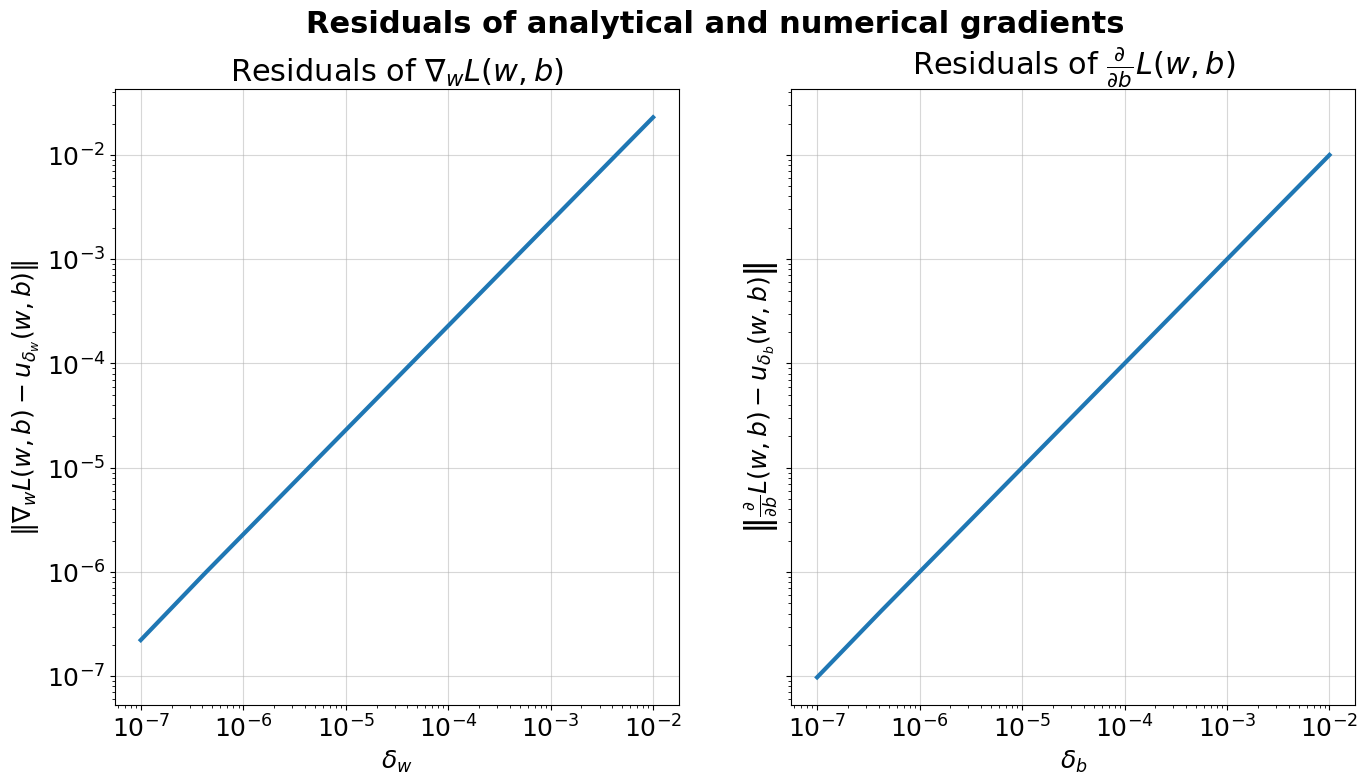

In [54]:
y_train = train_new["contamination_level"]
X_train = train_new.drop(["contamination_level"], axis=1)
compare_gradients(X_train, y_train, deltas=np.logspace(-7, -2, 9))

#Task

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def test_lr(X_train, y_train, X_val, y_val, title:str, max_iter = 1500):
  lr_list = np.logspace(-9, -1, 9)

  fig, axs = plt.subplots(3, 3, sharey=True, figsize=(20, 12))
  plt.suptitle(title, fontsize=32)
  plt.tight_layout()
  fig.subplots_adjust(hspace=0.5, top=0.9)

  axs = np.ravel(axs)
  for i, lr in enumerate(lr_list):
    cur_linear_reggressor = LinearRegressor(lr)
    train_losses, val_losses = cur_linear_reggressor.fit_with_logs(X_train, y_train, keep_losses=True, X_val=X_val, y_val=y_val, max_iter = max_iter)
    print('lr size = '+str(lr)+', Best train loss = '+str(min(train_losses))+', Best validation loss = '+str(min(val_losses)))

    iterations = np.arange(max_iter + 1)
    axs[i].semilogy(iterations, train_losses, label="Train")
    axs[i].semilogy(iterations, val_losses, label="Validation")
    axs[i].grid(alpha=0.5)
    axs[i].legend()
    axs[i].set_title('lr = '+str(lr))
    axs[i].set_xlabel('iteration')
    axs[i].set_ylabel('MSE')

#Q3

lr size = 1e-09, Best train loss = 5.1598487478451265, Best validation loss = 5.7228218716640695
lr size = 1e-08, Best train loss = 5.159735218728188, Best validation loss = 5.722701680037996
lr size = 1e-07, Best train loss = 5.158600337446271, Best validation loss = 5.721500178296591
lr size = 1e-06, Best train loss = 5.1472924099644475, Best validation loss = 5.7095265108493525
lr size = 1e-05, Best train loss = 5.038200201887348, Best validation loss = 5.593824752465067
lr size = 0.0001, Best train loss = 4.261299661226803, Best validation loss = 4.756554026534858
lr size = 0.001, Best train loss = 3.157064511125199, Best validation loss = 3.4605163099984417
lr size = 0.01, Best train loss = 2.6744577565621928, Best validation loss = 2.9208765258524996
lr size = 0.1, Best train loss = 2.6781164429255555, Best validation loss = 2.865098851490156


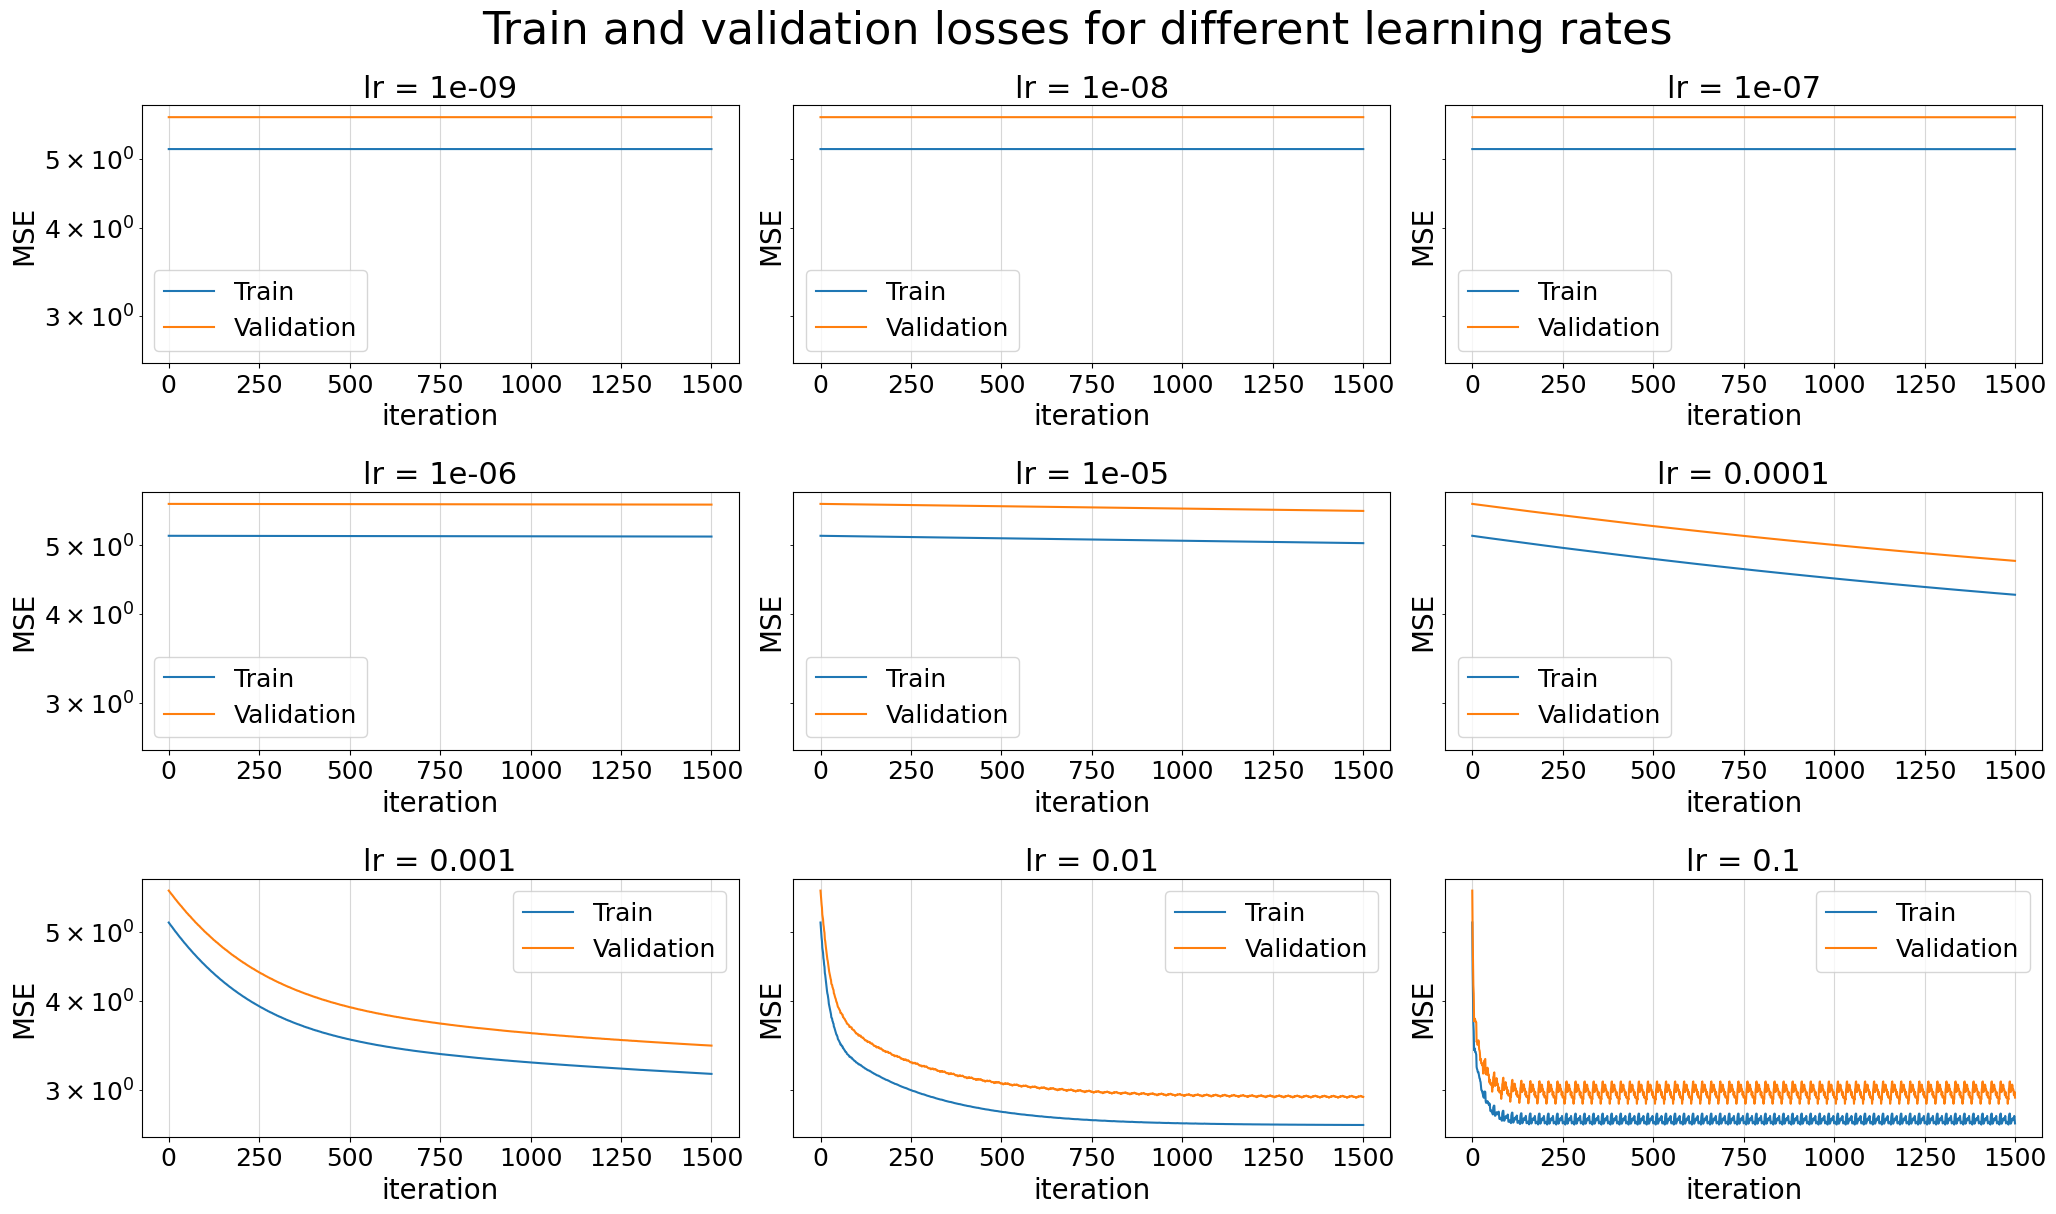

In [56]:
y_train = train_new["contamination_level"]
X_train = train_new.drop(["contamination_level"], axis=1)

y_val = validation["contamination_level"]
X_val = validation.drop(["contamination_level"], axis=1)

test_lr(X_train, y_train, X_val, y_val, "Train and validation losses for different learning rates")

## Section 2

#Q4

In [57]:
y_train_dummy = all_train_norm["contamination_level"]
X_train_dummy = all_train_norm.drop(["contamination_level"], axis=1)

In [58]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score ,cross_validate
from sklearn.metrics import mean_squared_error

def crossValidateMSE(Regressor_model ,X_train_dummy , y_train_dummy ):
    cv_results = cross_validate(Regressor_model, X_train_dummy, y_train_dummy, cv=5, scoring='neg_mean_squared_error',return_train_score = True)
    mse_train_loss = np.mean(-cv_results['train_score'])
    mse_validation_loss = np.mean(-cv_results['test_score'])
    return mse_train_loss ,mse_validation_loss

# Create a DummyRegressor
dummy_regressor = DummyRegressor(strategy="mean")
dummy_train_loss , dummy_validation_loss = crossValidateMSE(dummy_regressor , X_train_dummy ,y_train_dummy)

print("Train MSE Loss:", dummy_train_loss)
print("Validation MSE Loss:", dummy_validation_loss)

Train MSE Loss: 4.0157284908002335
Validation MSE Loss: 4.030222849704113


In [59]:
# dummy for Sec 6
dummy_sec_6 = DummyRegressor(strategy="mean")
dummy_sec_6.fit(X_train_dummy, y_train_dummy)

DummyRegressor()

#Q5

In [60]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

y_train_5 = all_train_norm["contamination_level"]
X_train_5 = all_train_norm.drop(["contamination_level"], axis=1)

# choose suitable lr values
lr_values = np.logspace(-9, -1, 9)

# Predefine cross-validation
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=74)

# for each lr, keep mean scores
train_scores = []
validation_scores = []

for lr in lr_values:
    LinearReg = LinearRegressor(lr)
    # Perform cross-validation and keep mean scores
    mse_train_loss ,mse_validation_loss = crossValidateMSE(LinearReg ,X_train_5, y_train_5)
    train_scores.append(mse_train_loss)
    validation_scores.append(mse_validation_loss)

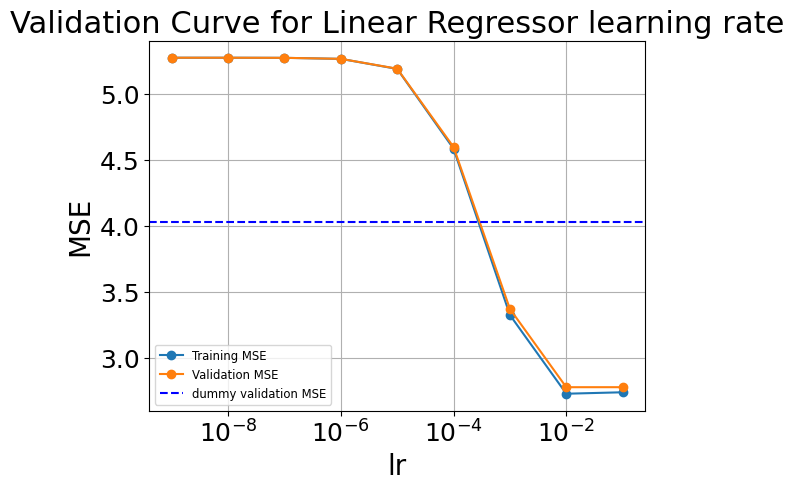

In [61]:
plt.semilogx(lr_values, train_scores, label='Training MSE', marker = 'o')
plt.semilogx(lr_values, validation_scores, label='Validation MSE', marker = 'o')
#TO DO: need to change value y according to the result in Q4 (VALIDATION MSE LOSS)
plt.axhline(y=dummy_validation_loss, color='blue', linestyle='--', label='dummy validation MSE')
plt.xlabel('lr')
plt.ylabel('MSE')
plt.title('Validation Curve for Linear Regressor learning rate')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True, which="both")
plt.show()

In [62]:
best_train_mse_loss = np.min(train_scores)
best_validation_mse_loss = np.min(validation_scores)
print("Train MSE Loss:", best_train_mse_loss)
print("Validation MSE Loss:", best_validation_mse_loss)

Train MSE Loss: 2.728693033347299
Validation MSE Loss: 2.778022792033902


#Task

In [63]:
# section 2 best model to be used in section 6

sec_2_best_lr_LinearReg = LinearRegressor(0.01)
sec_2_best_lr_LinearReg.fit(X_train_5, y_train_5)

LinearRegressor(lr=0.01)

## Section 3

#Q7

In [64]:
from sklearn.linear_model import Lasso

# choose suitable alpha values
alpha_values = np.logspace(-5, 5, 10)

# Predefine cross-validation
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=74)

# for each alpha, keep mean scores
train_scores = []
validation_scores = []

for a in alpha_values:
    lasso = Lasso(fit_intercept=True, alpha = a)
    # Perform cross-validation and keep mean scores
    mse_train_loss ,mse_validation_loss = crossValidateMSE(lasso, X_train_5, y_train_5)
    train_scores.append(mse_train_loss)
    validation_scores.append(mse_validation_loss)

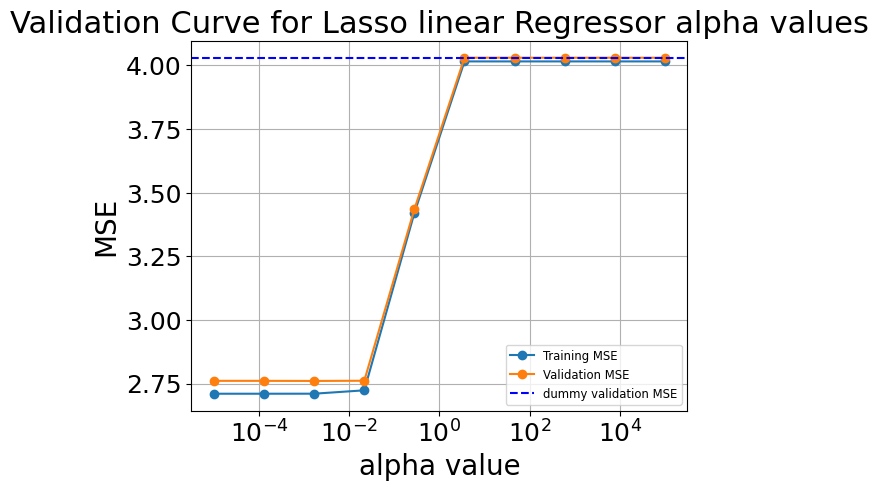

In [65]:
plt.semilogx(alpha_values, train_scores, label='Training MSE', marker = 'o')
plt.semilogx(alpha_values, validation_scores, label='Validation MSE', marker = 'o')
plt.axhline(y=dummy_validation_loss, color='blue', linestyle='--', label='dummy validation MSE')
plt.xlabel('alpha value')
plt.ylabel('MSE')
plt.title('Validation Curve for Lasso linear Regressor alpha values')
plt.legend(fontsize='small')
plt.grid(True, which="both")
plt.show()

In [66]:
train_mse_loss = np.min(train_scores)
validation_mse_loss = np.min(validation_scores)
print("Train MSE Loss:", train_mse_loss)
print("Validation MSE Loss:", validation_mse_loss)

Train MSE Loss: 2.71006964867819
Validation MSE Loss: 2.7602729089932216


#Task

In [67]:
# section 3 best model to be used in section 6

sec_3_best_alpha_lasso = Lasso(fit_intercept=True, alpha = 0.001)
sec_3_best_alpha_lasso.fit(X_train_5, y_train_5)

Lasso(alpha=0.001)

#Q10

coefficient 0 value: 3.143851810047403
coefficient 3 value: 0.44014417008086515
coefficient 6 value: 0.19201296153080497
coefficient 1 value: 0.08750827057256956
coefficient 2 value: 0.08487740829380547
coefficient 8 value: 0.0830210788393459
coefficient 7 value: 0.06170357412738932
coefficient 10 value: 0.041718741749903906
coefficient 4 value: 0.04136012405118395
coefficient 9 value: 0.008019575521933853
coefficient 5 value: 0.0005604346766482052


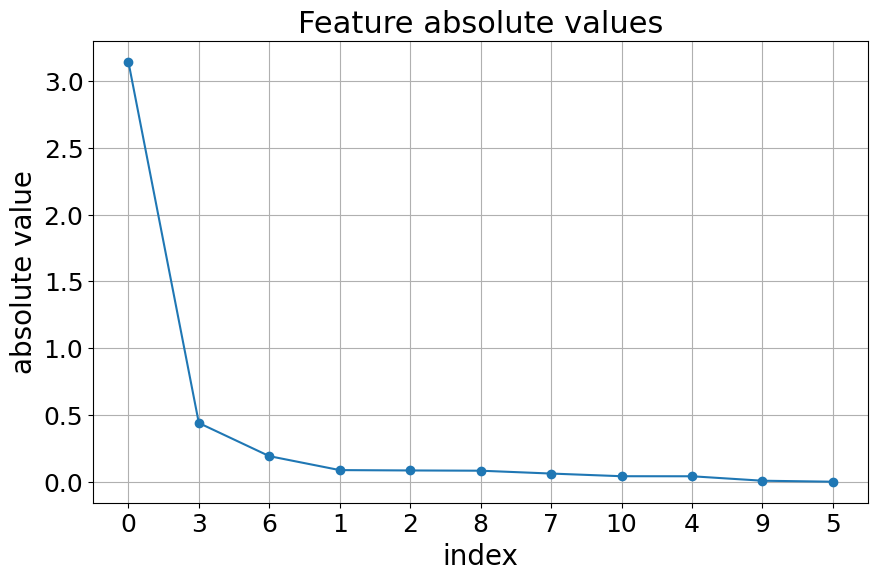

In [68]:
w = sec_3_best_alpha_lasso.coef_

# argsort in descending order the absolute values of the coefficients
sorted_indexs = np.argsort(-np.abs(w))

for i in sorted_indexs:
  print(f"coefficient {i} value: {np.abs(w)[i]}")

# plot the sort absolute values of the learned coefficients
plt.figure(figsize=(10, 6))
plt.plot(np.abs(w)[sorted_indexs], marker='o')
plt.xticks(range(0,len(w)), sorted_indexs)
plt.title('Feature absolute values')
plt.xlabel('index')
plt.ylabel('absolute value')
plt.grid(True)
plt.show()

#section 4

In [69]:
sec_4_train = all_train_norm[["PCR_03", "PCR_07", "contamination_level"]]

In [70]:
def plot3d(df, colX:str, colY:str, colZ:str, title:str, predictions=None):
  fig = plt.figure(figsize=(20, 7))
  axes = [fig.add_subplot(1, 3, i+1, projection='3d') for i in range(3)]

  palette = sns.color_palette("hls", 2)

  for i,ax in enumerate(axes):
    if predictions is not None:
      ax.scatter3D(df[colX], df[colY], predictions, color=palette[1], s=3)
      ax.scatter3D(df[colX], df[colY], df[colZ], color=palette[0], s=1,
                   alpha=0.35, depthshade=False)
    else:
      ax.scatter3D(df[colX], df[colY], df[colZ], color=palette[0], s=1)

    ax.set_xlabel(colX)
    ax.set_ylabel(colY)
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])

    ax.view_init(elev=5., azim=45*i)

  axes[0].set_zlabel("\n" + colZ, linespacing=2.2)

  plt.suptitle(title, fontsize=32)
  plt.tight_layout()
  plt.show()

<ipython-input-70-8d1e5cb89966>:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


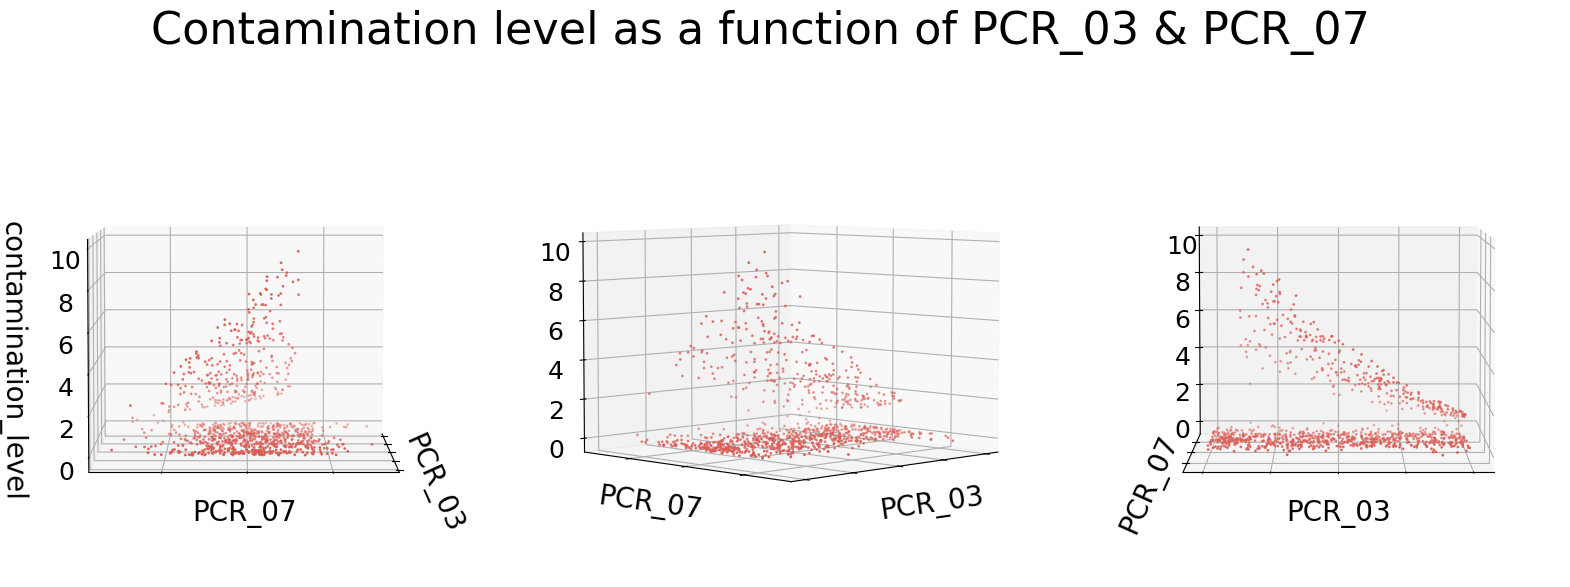

In [71]:
plot3d(sec_4_train, colX = "PCR_03", colY = "PCR_07", colZ = "contamination_level",
       title = "Contamination level as a function of PCR_03 & PCR_07", predictions=None)

#Task

In [72]:
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.pipeline import Pipeline

y_train = sec_4_train["contamination_level"]
X_train = sec_4_train.drop(["contamination_level"], axis=1)

# Creating Pipeline
poly_reg = Pipeline([('feature_mapping', PolynomialFeatures(degree=3)),
                     ('normalization', MinMaxScaler()),
                     ('Lasso', Lasso(alpha=0.01, fit_intercept=True))])

## Q15

best train MSE: 3.5552990165703413
best validation MSE: 3.5994214070480446


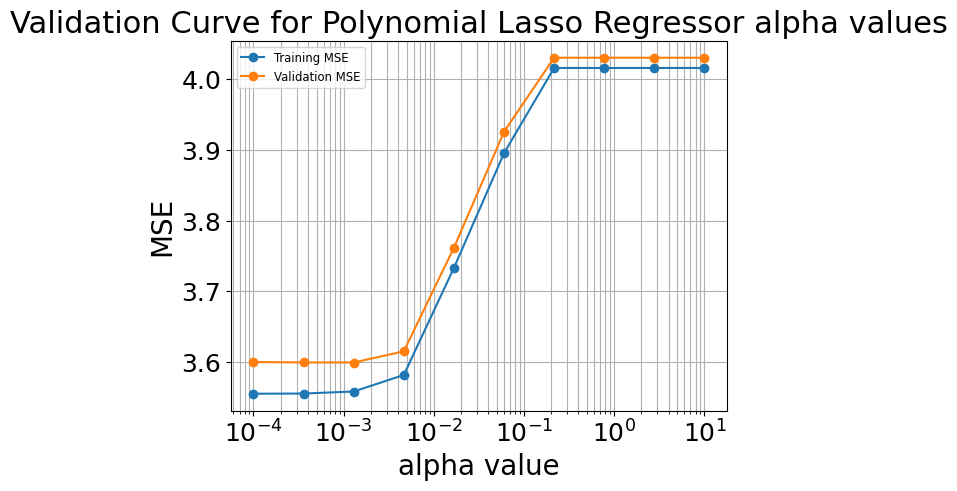

In [73]:

train_mean_scores = []
validation_mean_scores = []

a_values = np.logspace(-4,1,10)

for alpha in a_values:
    p = Pipeline([('feature_mapping', PolynomialFeatures(degree=3)),
                 ('normalization', MinMaxScaler()),
                 ('Lasso', Lasso(alpha=alpha, fit_intercept=True))])
    cv_results = cross_validate(p, X_train, y_train, cv=5, scoring='neg_mean_squared_error',return_train_score = True)
    train_scores = -cv_results['train_score']
    validation_scores = -cv_results['test_score']
    train_mean_scores.append(np.mean(train_scores))
    validation_mean_scores.append(np.mean(validation_scores))

print(f"best train MSE: {np.min(train_mean_scores)}")
print(f"best validation MSE: {np.min(validation_mean_scores)}")

plt.semilogx(a_values, train_mean_scores, label='Training MSE', marker = 'o')
plt.semilogx(a_values, validation_mean_scores, label='Validation MSE', marker = 'o')
plt.xlabel('alpha value')
plt.ylabel('MSE')
plt.title('Validation Curve for Polynomial Lasso Regressor alpha values')
plt.legend(fontsize='small')
plt.grid(True, which="both")
plt.show()


## Task

In [74]:
# section 4 best model to be used in section 6

sec_4_poly_reg = Pipeline([('feature_mapping', PolynomialFeatures(degree=3)),
                     ('normalization', MinMaxScaler()),
                     ('Lasso', Lasso(alpha=0.001, fit_intercept=True))])
sec_4_poly_reg.fit(X_train, y_train)

Pipeline(steps=[('feature_mapping', PolynomialFeatures(degree=3)),
                ('normalization', MinMaxScaler()),
                ('Lasso', Lasso(alpha=0.001))])

## Q16

<ipython-input-70-8d1e5cb89966>:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


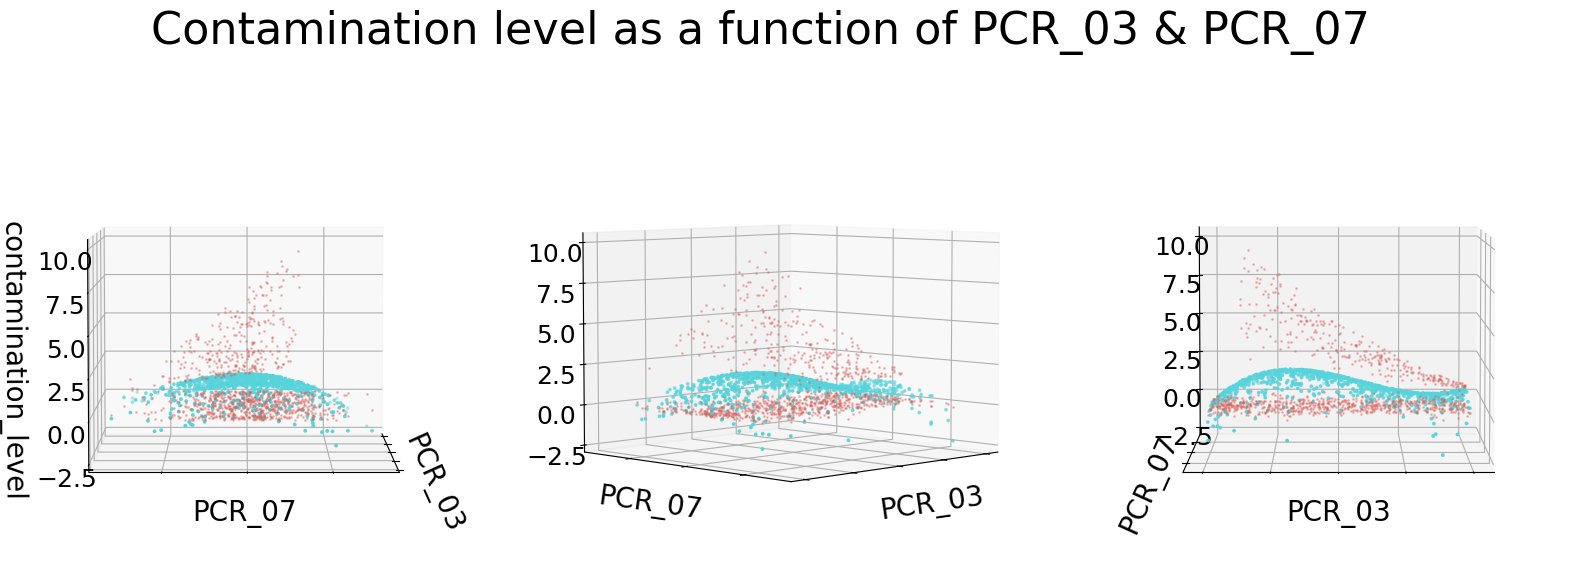

In [75]:
plot3d(sec_4_train, colX = "PCR_03", colY = "PCR_07", colZ = "contamination_level",
       title = "Contamination level as a function of PCR_03 & PCR_07", predictions=sec_4_poly_reg.predict(X_train))

## Section 5

In [88]:
sec_5_train = all_train_norm[["PCR_03", "PCR_07", "PCR_01", "PCR_08", "happiness_score", "contamination_level"]]

X_train = sec_5_train.drop(["contamination_level"], axis=1)
y_train = sec_5_train["contamination_level"]



the best parameters are {'learning_rate': 1, 'min_samples_split': 4}


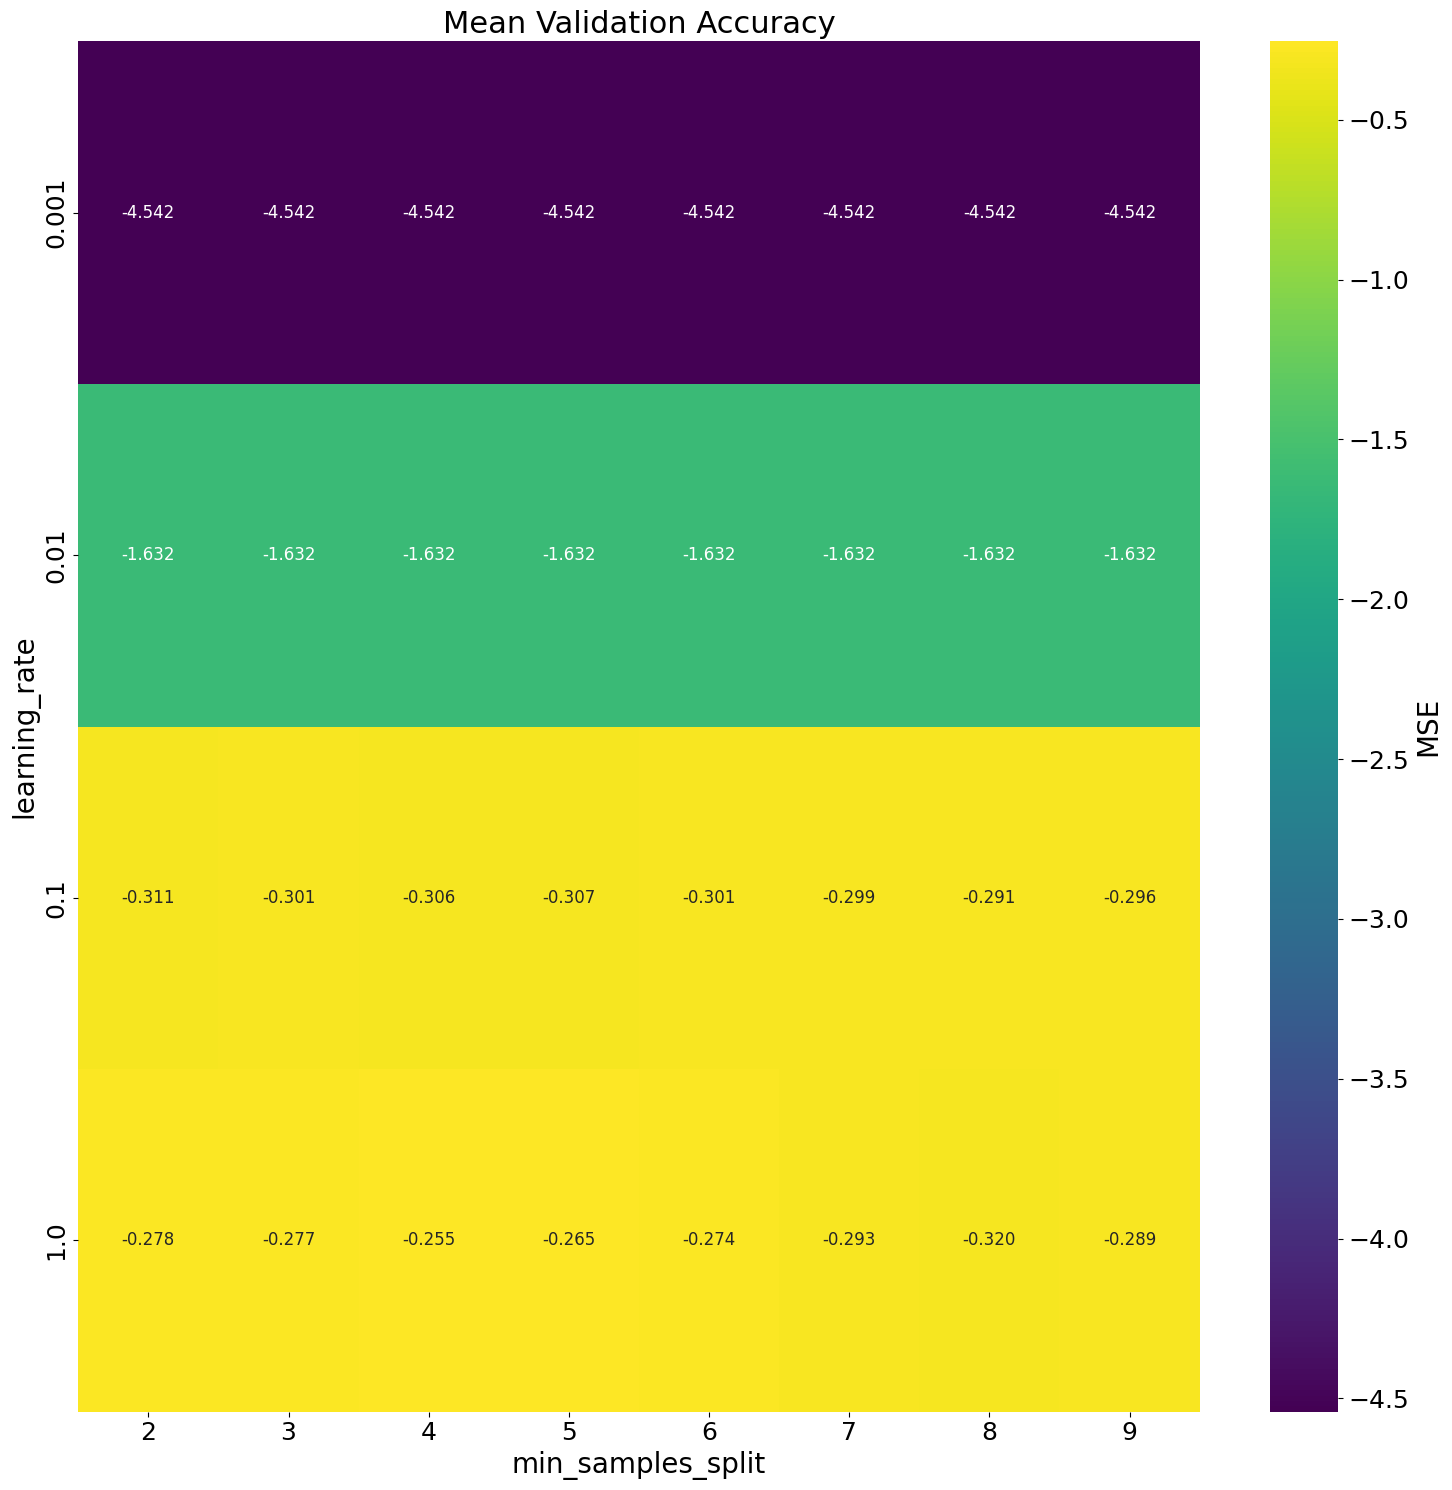

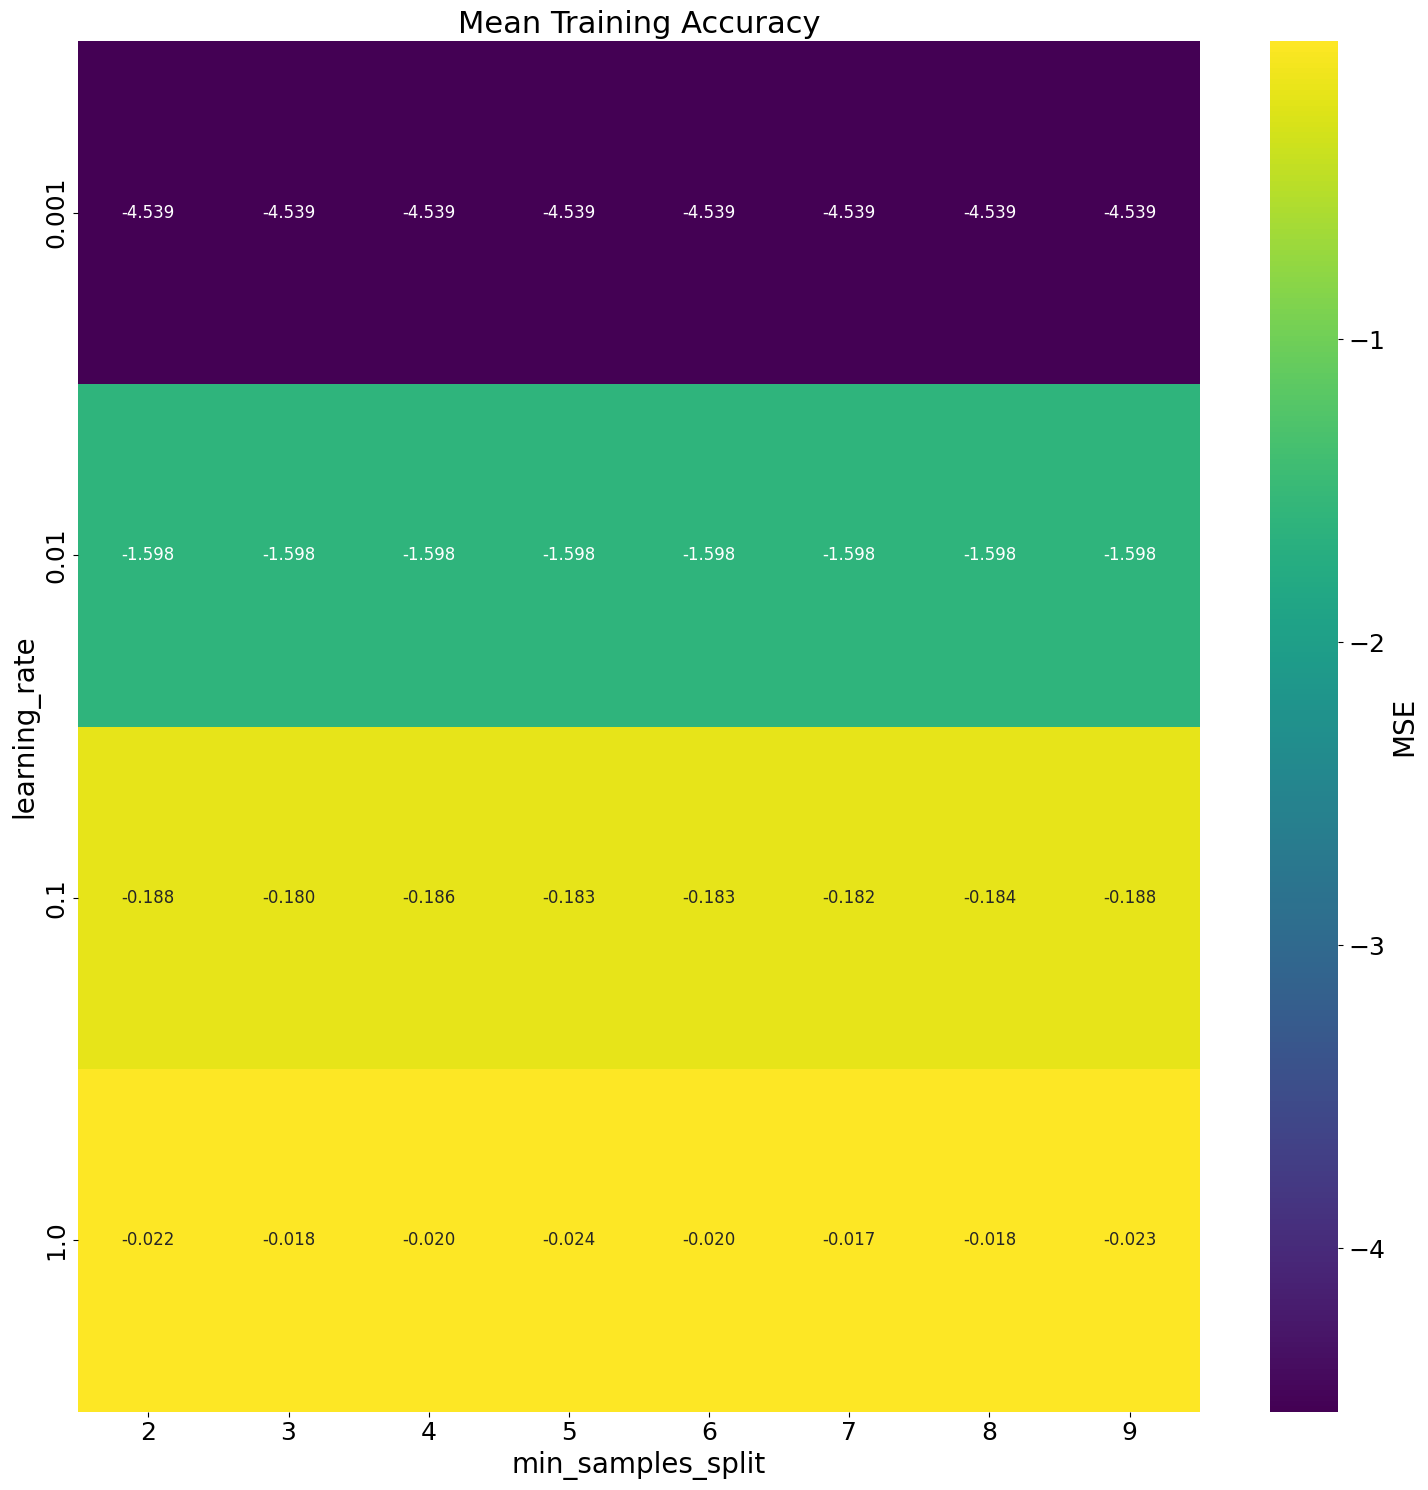

In [89]:
from sklearn.model_selection import GridSearchCV
import seaborn
from sklearn.ensemble import GradientBoostingRegressor

grad_boost_reg = GradientBoostingRegressor(loss='huber', random_state=74)
parameters = {
    'learning_rate': [0.001, 0.01, 0.1,1],
    'min_samples_split': [2,3,4,5,6,7,8,9]
}

grid_search = GridSearchCV(grad_boost_reg, parameters, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train, y_train)

# Finding best parameters
best_params = grid_search.best_params_
print("the best parameters are", best_params)

# Move to a DataFrame from grid_search.cv_results_
results = pd.DataFrame(grid_search.cv_results_)

# Reshape the mean training and validation scores into matrices and pivot the DataFrame for mean training scores & mean validation scores
train_matrix = results.pivot(index='param_learning_rate', columns='param_min_samples_split', values='mean_train_score')
validation_matrix = results.pivot(index='param_learning_rate', columns='param_min_samples_split', values='mean_test_score')

# Validation set accuracy heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(validation_matrix, annot=True, cmap="viridis", fmt=".3f", cbar_kws={'label': 'MSE'}, annot_kws={"size": 12})
plt.title('Mean Validation Accuracy')
plt.xlabel('min_samples_split')
plt.ylabel('learning_rate')
plt.tight_layout()
plt.show()

# Training set accuracy heatmap
plt.figure(figsize=(15, 15))
sns.heatmap(train_matrix, annot=True, cmap="viridis", fmt=".3f", cbar_kws={'label': 'MSE'}, annot_kws={"size": 12})
plt.title('Mean Training Accuracy')
plt.xlabel('min_samples_split')
plt.ylabel('learning_rate')
plt.tight_layout()
plt.show()

## Task

In [90]:
# section 5 best model to be used in section 6

sec_5_best_model = GradientBoostingRegressor(learning_rate = 1, min_samples_leaf = 4, loss='huber', random_state=74)
sec_5_best_model.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=1, loss='huber', min_samples_leaf=4,
                          random_state=74)

## Section 6

In [91]:
X_test = all_test_norm.drop(["contamination_level"], axis=1)
y_test = all_test_norm["contamination_level"]

y_pred = dummy_sec_6.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("dummy test MSE:", mse)

# Section 2

y_pred = sec_2_best_lr_LinearReg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("section 2 test MSE:", mse)

# Section 3

y_pred = sec_3_best_alpha_lasso.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("section 3 test MSE:", mse)

# Section 4

X_test = all_test_norm[["PCR_03", "PCR_07", "contamination_level"]].drop(["contamination_level"], axis=1)
y_test = all_test_norm["contamination_level"]

y_pred = sec_4_poly_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("section 4 test MSE:", mse)


# Section 5

X_test = all_test_norm[["PCR_03", "PCR_07", "PCR_01", "PCR_08", "happiness_score", "contamination_level"]].drop(["contamination_level"], axis=1)
y_test = all_test_norm["contamination_level"]

y_pred = sec_5_best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("section 5 test MSE:", mse)

dummy test MSE: 4.024910746747157
section 2 test MSE: 3.1098585055784462
section 3 test MSE: 3.3149810696524074
section 4 test MSE: 3.667277356782105
section 5 test MSE: 0.255883753090327
